In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
# import quantstats as qs

import matplotlib.pyplot as plt

In [9]:
# downloading S&P 500 index data from Yahoo Finance
spx = yf.download('SPY', start='2000-01-01', end='2023-01-01', auto_adjust = True)

# Extracting the closing prices
close_prices = spx['Close']
volume = spx['Volume']

[*********************100%***********************]  1 of 1 completed


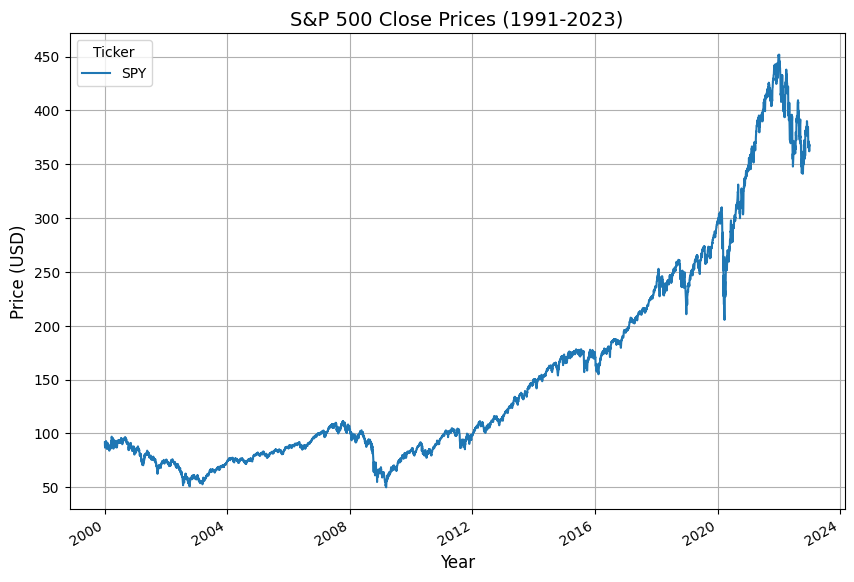

In [4]:
close_prices.plot(figsize=(10, 7), linewidth=1.5)
plt.title('S&P 500 Close Prices (1991-2023)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)
plt.show()

### Sample Strategy

In [18]:
# Calculating Moving Averages (Indicators)
short_window = 50
long_window = 252

short_ma = close_prices.rolling(window=short_window, min_periods=short_window).mean()
long_ma = close_prices.rolling(window=long_window, min_periods=long_window).mean()

# Generating Trading Signals
signals = pd.DataFrame(index=close_prices.index)
signals['signal'] = 0.0  # Set the default to be 0
signals['short_ma'] = short_ma
signals['long_ma'] = long_ma

# When the short is above the long, buy - else go short sell.
# Note that our signal is just a simple buy or sell, -1 or 1.
signals['signal'][signals['short_ma'] > signals['long_ma']] = 1
signals['signal'][signals['short_ma'] < signals['long_ma']] = -1

# Set the target volatility level
tgt_vol = 0.15

# Calculate daily percentage returns of SPX
spx_returns = close_prices.pct_change()

# Calculate the rolling annual standard deviation of SPX returns
signals['stdev'] = spx_returns.rolling(22).std() * np.sqrt(252)  # Convert to annualized standard deviation

# Calculate volatility target weights
signals['vol_tgt'] = tgt_vol / signals['stdev']

# Clip weights to a maximum of 1 to avoid leverage
# Here we use 2x leverage to make sure we can hit our volatility target of 15%
signals['vol_tgt'] = signals['vol_tgt'].clip(0, 2)

# Adjust the signal by the volatility target, lagging both to avoid look-ahead bias
vol_signal = signals['signal'].shift(1) * signals['vol_tgt'].shift(1)

# Compute returns for the volatility-targeted strategy
strategy_voltgt_returns = spx_returns.mul(vol_signal, axis = 0)

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_96909/2297329330.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  signals['signal'][signals['short_ma'] > signals['long_ma']] = 1
/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T

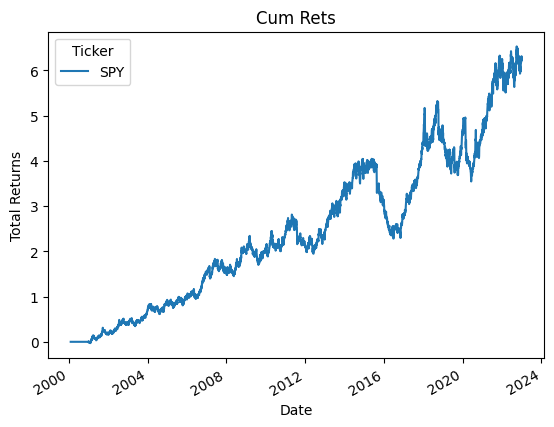

In [19]:
# Plot the cumulative rets (compounded growth)
((strategy_voltgt_returns + 1).cumprod()-1).plot(title='Cum Rets')
plt.ylabel('Total Returns')
plt.show()


In [ ]:
broker_fee = 0.0020 # 20 basis points
